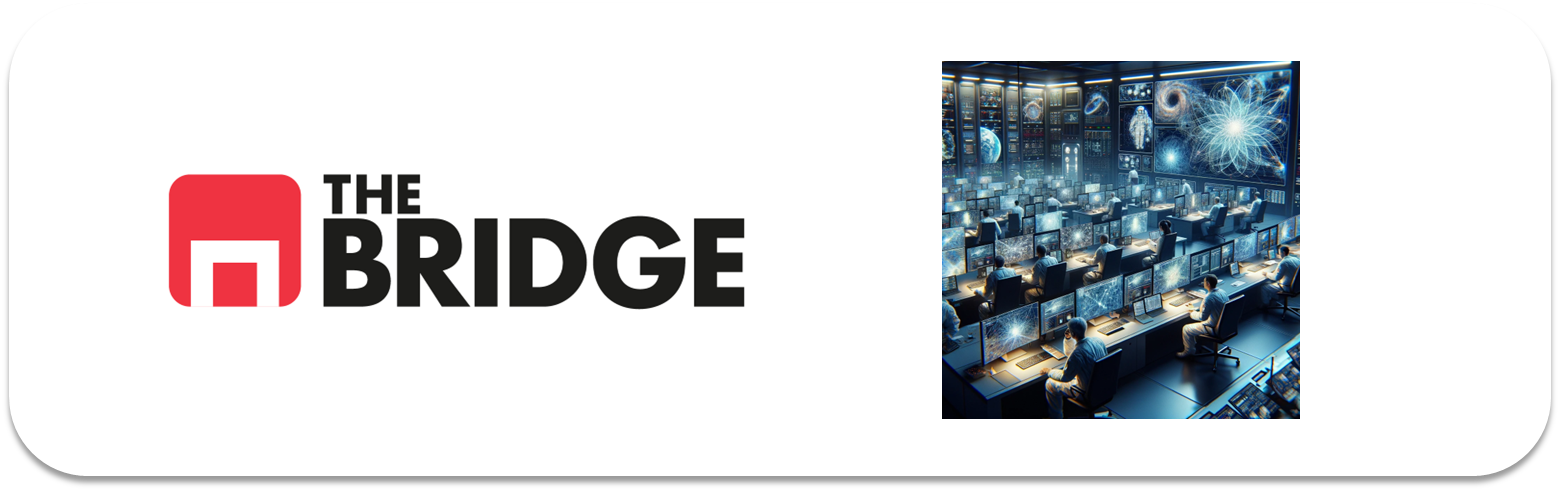

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import bootcampviztools as bt

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



### Ejercicio 1: Preparación de datos y funciones de visualización

Reutilizamos el planteamiento del ejercicio de clasificación de paisajes de la unidad anterior (dataset [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)): 6 clases (`buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`), ya organizadas en subcarpetas por clase dentro de `data/seg_train` y `data/seg_test`.

Elegimos **IM_SIZE = 96**, que es una de las resoluciones "canónicas" que admite MobileNetV2 preentrenada con pesos de ImageNet (96, 128, 160, 192 o 224), y la usaremos tanto para la CNN propia como para los modelos con transfer learning, así podemos comparar todo en igualdad de condiciones.

In [2]:
ROOT_PATH = "data/"
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
IM_SIZE = 96
CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))
print("Clases:", CLASS_NAMES)


def read_images(directorio, class_names, reshape_dim=(96, 96)):
    """Recorre las carpetas de clase de 'directorio', lee cada imagen, la redimensiona
    y le asigna como etiqueta el nombre de la carpeta (adaptado del ejercicio de paisajes)."""
    X = []
    y = []
    for class_name in class_names:
        class_dir = os.path.join(directorio, class_name)
        for file in os.listdir(class_dir):
            img = cv2.imread(os.path.join(class_dir, file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, reshape_dim)
            X.append(img)
            y.append(class_name)
    return np.array(X), np.array(y)


X_train, y_train_names = read_images(TRAIN_PATH, CLASS_NAMES, (IM_SIZE, IM_SIZE))
X_test, y_test_names = read_images(TEST_PATH, CLASS_NAMES, (IM_SIZE, IM_SIZE))

# Barajamos el train (las carpetas se han recorrido clase a clase, es decir ordenadas)
X_train, y_train_names = shuffle(X_train, y_train_names, random_state=42)

print("X_train:", X_train.shape, "y_train:", y_train_names.shape)
print("X_test:", X_test.shape, "y_test:", y_test_names.shape)

Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


X_train: (14034, 96, 96, 3) y_train: (14034,)
X_test: (3000, 96, 96, 3) y_test: (3000,)


#### Visualización

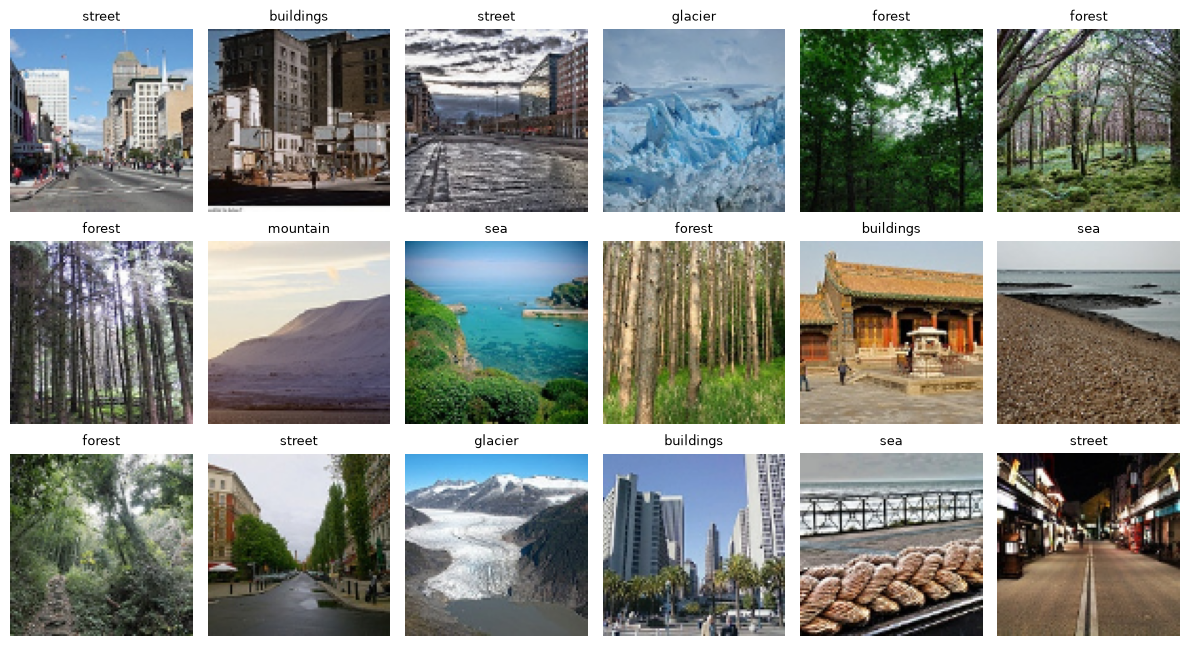

In [3]:
def plot_images(X, y_names, n_cols=6, indices=None):
    if indices is None:
        indices = np.random.choice(len(X), size=min(18, len(X)), replace=False)
    n_rows = (len(indices) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    for i, idx in enumerate(indices):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X[idx])
        plt.title(y_names[idx], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_images(X_train, y_train_names)

#### MiniEDA

Forma, tipo de dato, rango de píxeles y balance de clases.

Shape X_train: (14034, 96, 96, 3) - dtype: uint8
Rango de píxeles: [ 0 , 255 ]


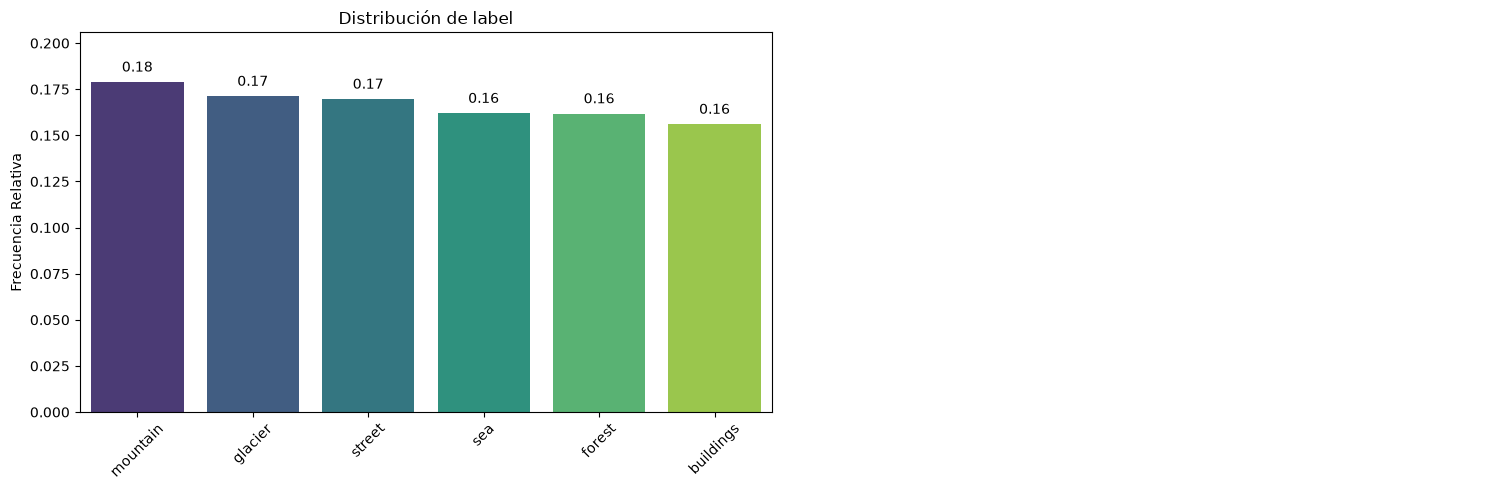

In [4]:
print("Shape X_train:", X_train.shape, "- dtype:", X_train.dtype)
print("Rango de píxeles: [", X_train.min(), ",", X_train.max(), "]")

bt.pinta_distribucion_categoricas(pd.DataFrame({"label": y_train_names}), ["label"], True, True)

Clases razonablemente equilibradas, así que "accuracy" nos sirve como métrica principal.

#### Transformación de features

Codificamos la etiqueta de texto a numérica (0-5) y preparamos **dos** normalizaciones distintas de los píxeles:
* `/255` para la CNN propia (rango [0,1], lo habitual para una red entrenada desde cero).
* `preprocess_input` de MobileNetV2 para los modelos con transfer learning/fine-tuning, porque espera los píxeles preprocesados exactamente igual que cuando se entrenó con ImageNet (rango aproximado [-1,1]).

In [5]:
label_to_int = {name: i for i, name in enumerate(CLASS_NAMES)}
int_to_label = {i: name for name, i in label_to_int.items()}

y_train_enc = np.array([label_to_int[label] for label in y_train_names])
y_test_enc = np.array([label_to_int[label] for label in y_test_names])

# Normalización para la CNN propia
X_train_cnn = X_train.astype("float32") / 255.0
X_test_cnn = X_test.astype("float32") / 255.0

# Normalización específica de MobileNetV2 para los modelos con transfer learning
X_train_mnv2 = preprocess_input(X_train.astype("float32"))
X_test_mnv2 = preprocess_input(X_test.astype("float32"))

print(label_to_int)
print("X_train_cnn range:", X_train_cnn.min(), X_train_cnn.max())
print("X_train_mnv2 range:", X_train_mnv2.min(), X_train_mnv2.max())

{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


X_train_cnn range: 0.0 1.0


X_train_mnv2 range: -1.0 1.0


Como vamos a evaluar varios modelos con exactamente los mismos pasos (evaluar, `classification_report`, matriz de confusión), montamos una función auxiliar para no repetir código y poder comparar resultados fácilmente al final.

In [6]:
results = {}  # aquí guardamos el accuracy de test de cada modelo para la comparación final


def plot_history(history, title=""):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    history_df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_xlabel("epochs")
    axes[0].set_ylabel("loss")
    axes[0].set_title(f"Pérdida {title}")

    acc_cols = [c for c in ["accuracy", "acc"] if c in history_df.columns]
    val_acc_cols = [c for c in ["val_accuracy", "val_acc"] if c in history_df.columns]
    history_df[acc_cols + val_acc_cols].plot(ax=axes[1])
    axes[1].set_xlabel("epochs")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title(f"Accuracy {title}")
    plt.tight_layout()
    plt.show()


def eval_and_report(model, X_test, y_test, model_name):
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"[{model_name}] Test loss: {test_loss:.4f} - Test accuracy: {test_accuracy:.4f}")

    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASS_NAMES, xticks_rotation=45)
    plt.title(model_name)
    plt.show()

    results[model_name] = test_accuracy
    return test_accuracy

### Red convolucional propia (baseline)

Antes de meternos con modelos preentrenados, entrenamos una CNN "ad-hoc" muy similar a la de la práctica obligatoria de la unidad anterior (dos juegos Convolucional-Pooling + cabeza densa), pero adaptada a las 6 clases de paisajes. La usaremos como referencia en el punto 6 para ver cuánto aporta realmente el transfer learning.

In [7]:
def build_baseline_cnn():
    model = Sequential([
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(IM_SIZE, IM_SIZE, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(len(CLASS_NAMES), activation="softmax"),
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,738,886 (18.08 MB)

 Trainable params: 4,738,886 (18.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


  1/351 ━━━━━━━━━━━━━━━━━━━━ 12:53 2s/step - accuracy: 0.1250 - loss: 1.9001

  2/351 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.1562 - loss: 2.5702

  3/351 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.1458 - loss: 2.6137

  4/351 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.1641 - loss: 2.5040

...

344/351 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8567 - loss: 0.3954

346/351 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8569 - loss: 0.3950

348/351 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8569 - loss: 0.3950

350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8571 - loss: 0.3943

351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.8571 - loss: 0.3945 - val_accuracy: 0.7834 - val_loss: 0.6803


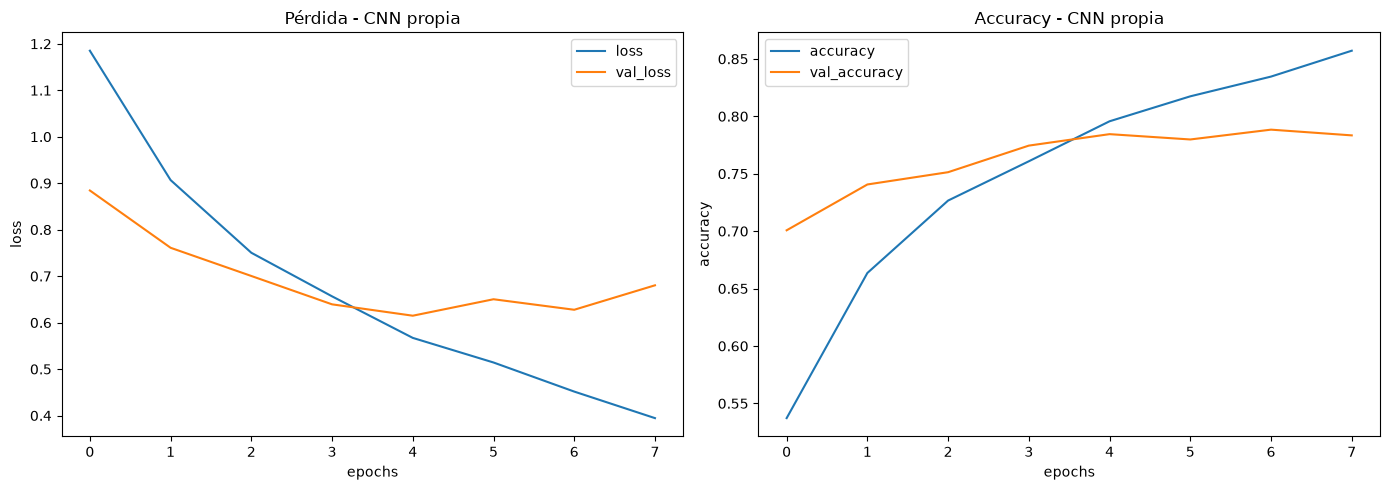

In [8]:
baseline_history = baseline_model.fit(
    X_train_cnn, y_train_enc,
    validation_split=0.2,
    batch_size=32,
    epochs=15,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)

plot_history(baseline_history, title="- CNN propia")

[CNN propia] Test loss: 0.6082 - Test accuracy: 0.7937


              precision    recall  f1-score   support

   buildings       0.75      0.77      0.76       437
      forest       0.96      0.91      0.93       474
     glacier       0.72      0.83      0.77       553
    mountain       0.75      0.74      0.74       525
         sea       0.78      0.72      0.75       510
      street       0.84      0.80      0.82       501

    accuracy                           0.79      3000
   macro avg       0.80      0.79      0.80      3000
weighted avg       0.80      0.79      0.79      3000



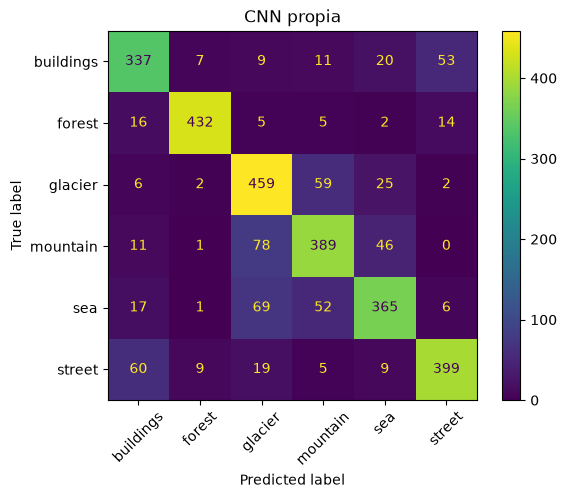

0.793666660785675

In [9]:
eval_and_report(baseline_model, X_test_cnn, y_test_enc, "CNN propia")

### Ejercicio 2: Elección del modelo preentrenado

Elegimos **MobileNetV2**, tal y como aconseja el enunciado si no se dispone de un ordenador muy potente: es una arquitectura ligera (pensada originalmente para móviles) que en CPU entrena mucho más rápido que VGG-19 o InceptionV3 mantiniendo buenas prestaciones. Cargamos el modelo base sin su cabeza (`include_top=False`) y con los pesos de ImageNet.

### Ejercicio 3 (enunciado: punto 4): Transfer Learning

Congelamos todas las capas de MobileNetV2 (no se van a entrenar) y le añadimos una cabeza propia con, como mucho, 2 capas densas ocultas y una de salida: `GlobalAveragePooling2D` (para no explotar el número de parámetros con un `Flatten`) + `Dense(128, relu)` + `Dropout` + `Dense(6, softmax)`.

In [10]:
def build_transfer_model(learning_rate=0.001):
    """Crea MobileNetV2 (congelada) + cabeza propia de 2 capas densas ocultas y 1 de salida."""
    base_model = MobileNetV2(input_shape=(IM_SIZE, IM_SIZE, 3), include_top=False, weights="imagenet")
    base_model.trainable = False

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

    model = Model(base_model.input, output)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model, base_model


transfer_model, transfer_base = build_transfer_model()
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,430,598 (9.27 MB)

 Trainable params: 172,614 (674.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/12


  1/351 ━━━━━━━━━━━━━━━━━━━━ 18:19 3s/step - accuracy: 0.2188 - loss: 2.4635

  3/351 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.2500 - loss: 2.1450

  5/351 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.3187 - loss: 1.9698

  7/351 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.3750 - loss: 1.7635

...

345/351 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9524 - loss: 0.1268

347/351 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9524 - loss: 0.1271

349/351 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9525 - loss: 0.1266

351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9522 - loss: 0.1270

351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9522 - loss: 0.1270 - val_accuracy: 0.9124 - val_loss: 0.2746


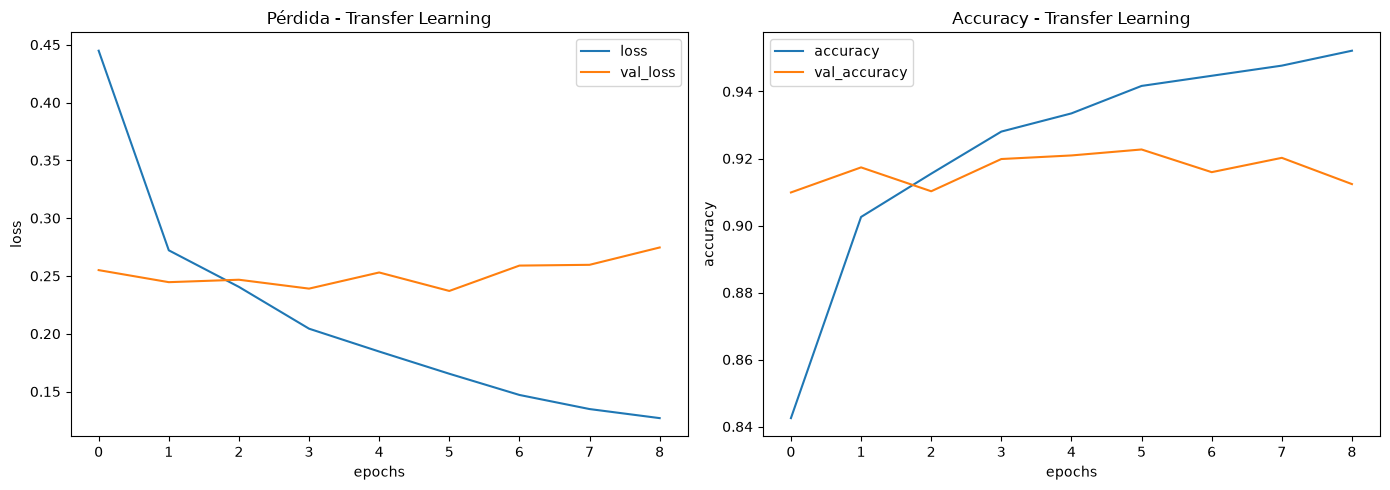

In [11]:
transfer_history = transfer_model.fit(
    X_train_mnv2, y_train_enc,
    validation_split=0.2,
    batch_size=32,
    epochs=12,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)

plot_history(transfer_history, title="- Transfer Learning")

[Transfer Learning (MobileNetV2)] Test loss: 0.2376 - Test accuracy: 0.9120


              precision    recall  f1-score   support

   buildings       0.94      0.89      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.87      0.82      0.84       553
    mountain       0.84      0.88      0.86       525
         sea       0.95      0.94      0.94       510
      street       0.91      0.96      0.93       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



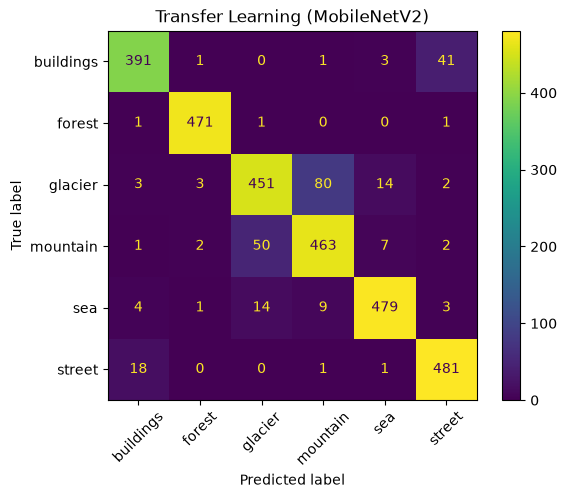

0.9120000004768372

In [12]:
eval_and_report(transfer_model, X_test_mnv2, y_test_enc, "Transfer Learning (MobileNetV2)")

### Ejercicio 4 (enunciado: punto 5): Fine-tuning

Partimos del mismo modelo ya entrenado (misma cabeza) y ahora descongelamos las capas superiores de MobileNetV2 (el último bloque, que captura características más específicas de las imágenes de ImageNet y es el que más nos interesa reajustar a nuestro problema) dejando el resto de la red congelada. Recompilamos con un **learning rate mucho más bajo** (`1e-5`) porque ya partimos de un modelo bastante bueno y no queremos destrozar los pesos preentrenados con pasos de gradiente grandes.

In [13]:
for indice, layer in enumerate(transfer_base.layers):
    if indice >= len(transfer_base.layers) - 20:  # descongelamos solo las últimas 20 capas
        layer.trainable = True

print("Capas entrenables en la base:", sum(l.trainable for l in transfer_base.layers), "de", len(transfer_base.layers))

transfer_model.compile(optimizer=Adam(learning_rate=1e-5),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

Capas entrenables en la base: 20 de 154


Epoch 1/6


  1/351 ━━━━━━━━━━━━━━━━━━━━ 25:23 4s/step - accuracy: 0.8438 - loss: 0.6885

  2/351 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.7969 - loss: 0.8306

  4/351 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - accuracy: 0.8203 - loss: 0.6306

  6/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.7969 - loss: 0.7141

...

347/351 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9312 - loss: 0.1844

348/351 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9312 - loss: 0.1846

349/351 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9313 - loss: 0.1844

351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9314 - loss: 0.1841

351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9314 - loss: 0.1841 - val_accuracy: 0.9223 - val_loss: 0.2511


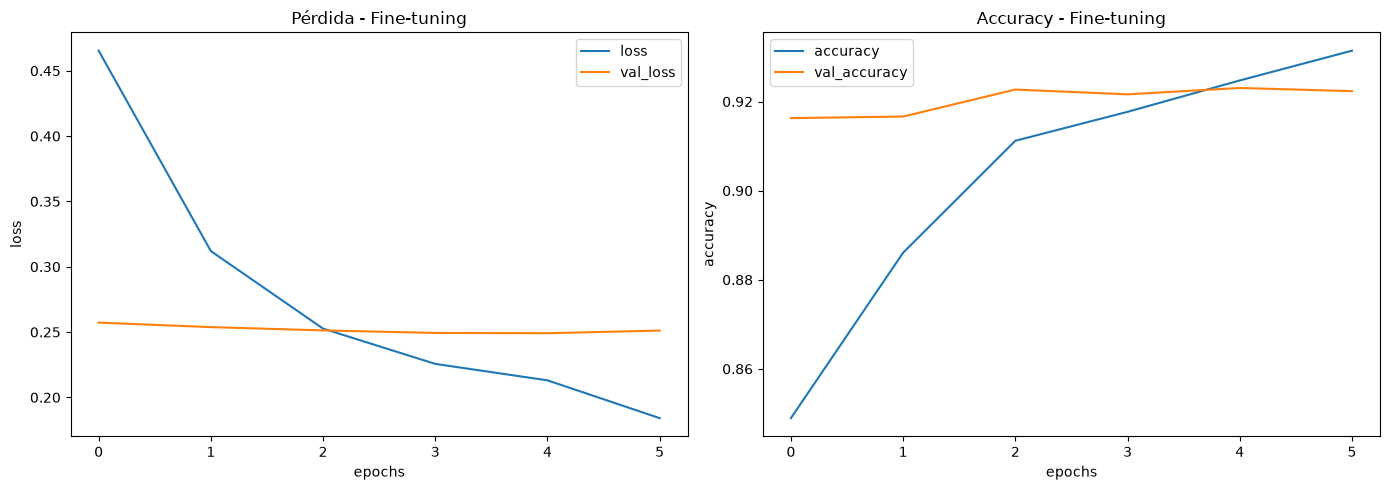

In [14]:
finetune_history = transfer_model.fit(
    X_train_mnv2, y_train_enc,
    validation_split=0.2,
    batch_size=32,
    epochs=6,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
)

plot_history(finetune_history, title="- Fine-tuning")

[Fine-tuning (MobileNetV2)] Test loss: 0.2595 - Test accuracy: 0.9080


              precision    recall  f1-score   support

   buildings       0.93      0.87      0.90       437
      forest       0.98      0.99      0.99       474
     glacier       0.86      0.84      0.85       553
    mountain       0.86      0.85      0.86       525
         sea       0.94      0.94      0.94       510
      street       0.90      0.96      0.93       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



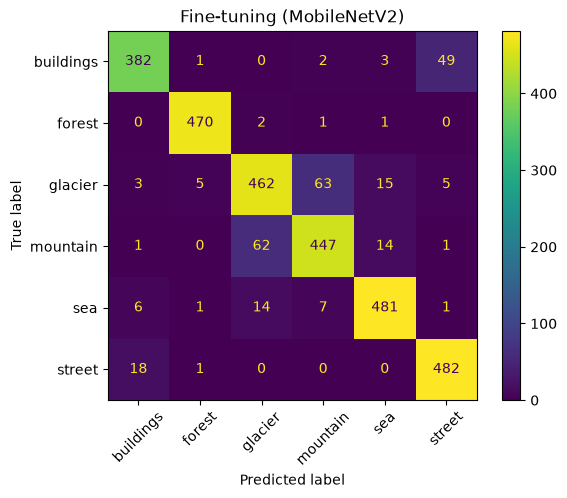

0.9079999923706055

In [15]:
eval_and_report(transfer_model, X_test_mnv2, y_test_enc, "Fine-tuning (MobileNetV2)")

### Ejercicio 5 (enunciado: punto 6): Comparación de resultados

,test_accuracy
Transfer Learning (MobileNetV2),0.912000
Fine-tuning (MobileNetV2),0.908000
CNN propia,0.793667


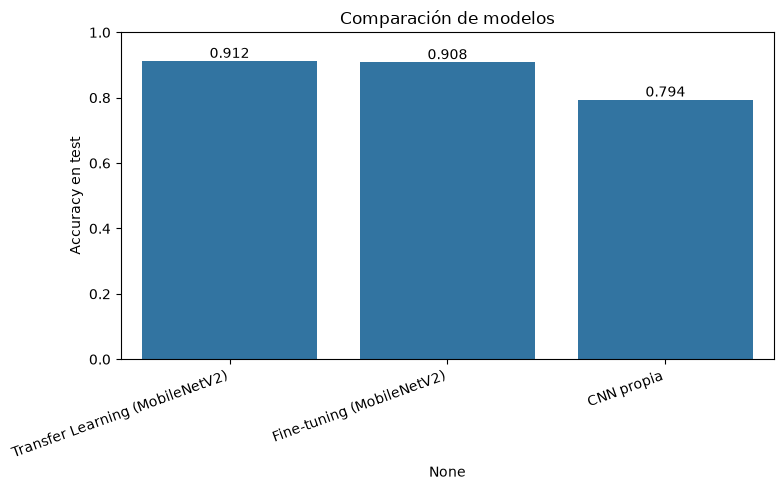

In [16]:
comparison_df = pd.Series(results, name="test_accuracy").sort_values(ascending=False).to_frame()
display(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df["test_accuracy"])
plt.ylabel("Accuracy en test")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Comparación de modelos")
for i, v in enumerate(comparison_df["test_accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

### Extra: Transfer Learning con Image Augmentation

Repetimos el transfer learning (modelo nuevo, misma arquitectura de cabeza, base congelada) pero esta vez generando variaciones sintéticas de las imágenes de train. Como los datos ya están organizados en subcarpetas por clase, usamos `flow_from_directory` en vez de cargar arrays a mano: es más cómodo y no necesitamos tener todas las imágenes aumentadas en memoria a la vez.

Usamos `preprocessing_function=preprocess_input` para que las imágenes generadas se normalicen exactamente igual que las que espera MobileNetV2.

In [17]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2,
)

train_generator = datagen.flow_from_directory(
    TRAIN_PATH,
    classes=CLASS_NAMES,
    target_size=(IM_SIZE, IM_SIZE),
    batch_size=32,
    class_mode="sparse",
    subset="training",
    seed=42,
)
val_generator = datagen.flow_from_directory(
    TRAIN_PATH,
    classes=CLASS_NAMES,
    target_size=(IM_SIZE, IM_SIZE),
    batch_size=32,
    class_mode="sparse",
    subset="validation",
    seed=42,
)

Found 11230 images belonging to 6 classes.


Found 2804 images belonging to 6 classes.


Epoch 1/10


  1/351 ━━━━━━━━━━━━━━━━━━━━ 33:36 6s/step - accuracy: 0.1250 - loss: 2.1982

  2/351 ━━━━━━━━━━━━━━━━━━━━ 32s 94ms/step - accuracy: 0.2188 - loss: 2.0611

  3/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.2604 - loss: 2.0301

  4/351 ━━━━━━━━━━━━━━━━━━━━ 33s 96ms/step - accuracy: 0.2734 - loss: 1.9392

...

348/351 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8933 - loss: 0.2923

349/351 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8933 - loss: 0.2927

350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8932 - loss: 0.2928

351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8931 - loss: 0.2934

351/351 ━━━━━━━━━━━━━━━━━━━━ 31s 87ms/step - accuracy: 0.8931 - loss: 0.2934 - val_accuracy: 0.8894 - val_loss: 0.3326


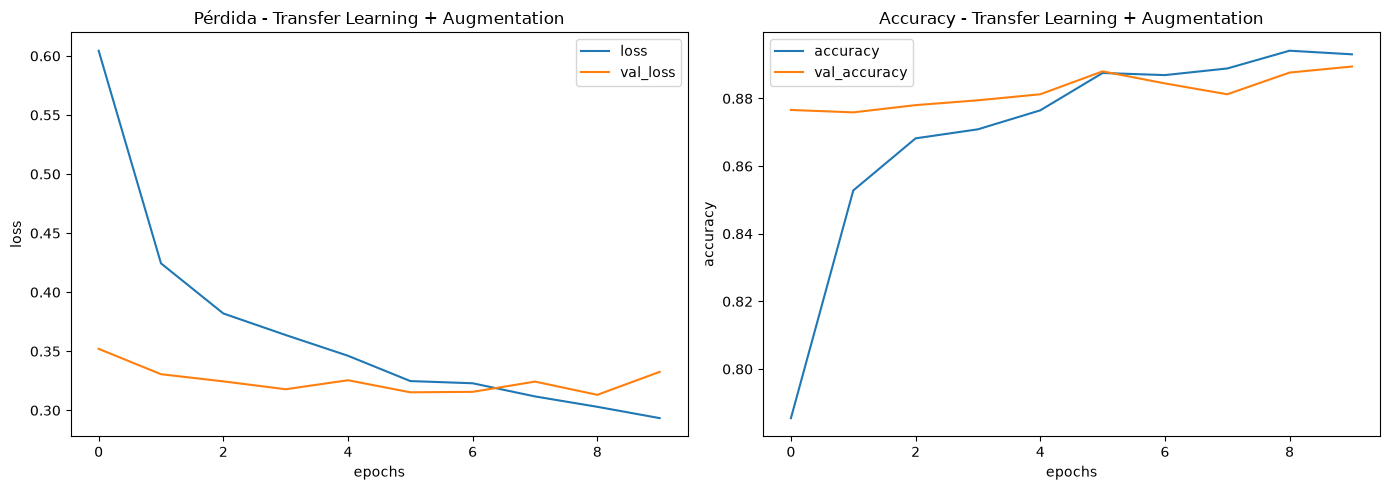

In [18]:
augmented_model, _ = build_transfer_model()

augmented_history = augmented_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)

plot_history(augmented_history, title="- Transfer Learning + Augmentation")

[Transfer Learning + Augmentation] Test loss: 0.2620 - Test accuracy: 0.9037


              precision    recall  f1-score   support

   buildings       0.90      0.89      0.90       437
      forest       1.00      0.98      0.99       474
     glacier       0.89      0.79      0.84       553
    mountain       0.82      0.90      0.86       525
         sea       0.95      0.94      0.95       510
      street       0.88      0.94      0.91       501

    accuracy                           0.90      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.90      0.90      3000



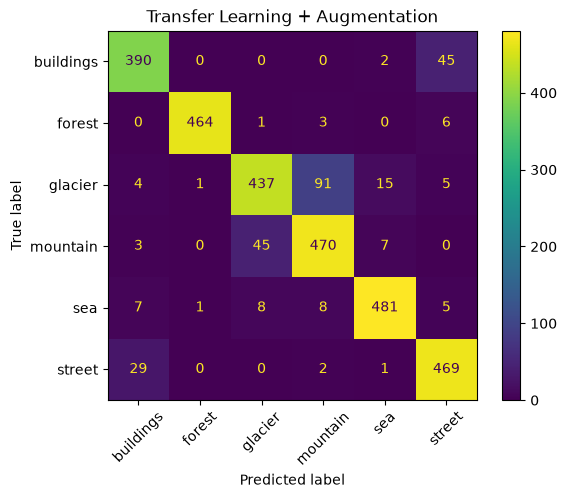

0.9036666750907898

In [19]:
eval_and_report(augmented_model, X_test_mnv2, y_test_enc, "Transfer Learning + Augmentation")

,test_accuracy
Transfer Learning (MobileNetV2),0.912000
Fine-tuning (MobileNetV2),0.908000
Transfer Learning + Augmentation,0.903667
CNN propia,0.793667


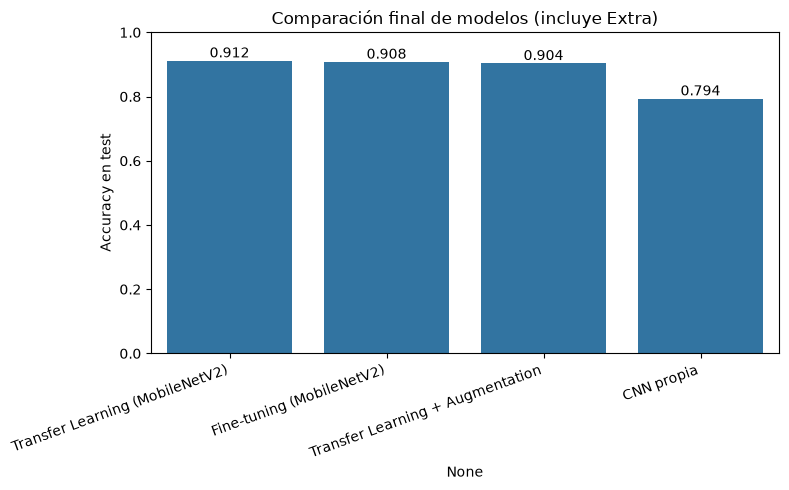

In [20]:
comparison_df = pd.Series(results, name="test_accuracy").sort_values(ascending=False).to_frame()
display(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df["test_accuracy"])
plt.ylabel("Accuracy en test")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.title("Comparación final de modelos (incluye Extra)")
for i, v in enumerate(comparison_df["test_accuracy"]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()